In [2]:
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


N_CLUSTER = 8

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [3]:
FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

In [4]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [5]:
def advanced_clean_text(text):
    # Define domain-specific stopwords
    custom_stopwords = {'points', 'interest', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)

In [6]:
combined_details_df = pd.read_csv("../data/combined_details.csv")
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_42809/2128574053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [7]:
filtered_df = combined_details_df[(combined_details_df['tags']).str.lower().str.contains('landmark', na=False)]

In [8]:
filtered_df[['name', 'tags']]

,name,tags
5,Doi Chang Mub Arboretum,"Points of Interest & Landmarks, Lookouts"
7,Golden Triangle,Points of Interest & Landmarks
17,Wat Lai,Points of Interest & Landmarks
26,Wat Sao Thong Thong,"Points of Interest & Landmarks, Sacred & Relig..."
28,Kraison Siharat Hall,Points of Interest & Landmarks
...,...,...
1734,Wat Traphang Thong,"Points of Interest & Landmarks, Sacred & Relig..."
1736,Chiang Chom Temple (Wat Chedi Plong Pagoda),Points of Interest & Landmarks
1742,Ayutthaya Historical Park,"Historic Sites, Ancient Ruins, Architectural B..."
1745,Wat Wichian Bamrung,"Sacred & Religious Sites, Points of Interest &..."


In [9]:
combined_details_df['cleaned_tags'] = combined_details_df['tags'].apply(advanced_clean_text)

In [10]:
CONST_VECTOR_SIZE = 100
CONST_DIM_WINDOWS = 5

In [11]:
sentences = combined_details_df['cleaned_tags'].str.split()  # Tokenized tags
word2vec_model = Word2Vec(sentences, vector_size=CONST_VECTOR_SIZE, window=CONST_DIM_WINDOWS, min_count=1, workers=4)
# Compute TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(combined_details_df['cleaned_tags'])

In [12]:
def get_weighted_embedding(text):
    words = text.split()
    word_vecs = [word2vec_model.wv[word] * tfidf.idf_[tfidf.vocabulary_[word]] 
                 for word in words if word in word2vec_model.wv and word in tfidf.vocabulary_]
    return np.mean(word_vecs, axis=0) if word_vecs else np.zeros(word2vec_model.vector_size)

# Apply to dataset
combined_details_df['vectorized_tags'] = combined_details_df['cleaned_tags'].apply(get_weighted_embedding)

In [13]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# แปลงทุกประโยคเป็นเวกเตอร์
sentence_vectors = np.array([sentence_vector(sentence, word2vec_model) for sentence in sentences])


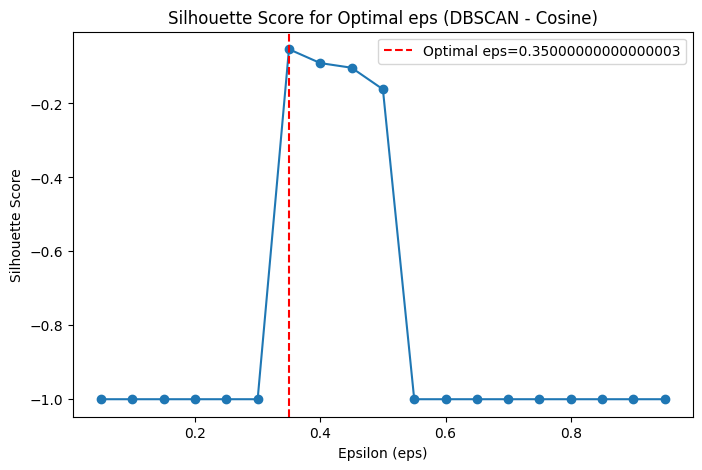

In [14]:
from sklearn.preprocessing import MinMaxScaler

def find_optimal_eps(data, min_eps=0.1, max_eps=5.0, step=0.1):
    cosine_sim_matrix = cosine_similarity(data)
    
    # Normalize to ensure all values are in [0,1] range
    scaler = MinMaxScaler()
    cosine_distances = 1 - cosine_sim_matrix  # Convert similarity to distance
    cosine_distances = scaler.fit_transform(cosine_distances)  # Ensure all values ≥ 0

    best_eps = min_eps
    best_silhouette = -1
    silhouette_scores = []
    eps_values = np.arange(min_eps, max_eps, step)

    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=2, metric="precomputed")
        labels = dbscan.fit_predict(cosine_distances)

        # Ensure at least 2 clusters exist
        if len(set(labels)) > 1:
            silhouette_avg = silhouette_score(cosine_distances, labels)
            silhouette_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette:
                best_silhouette = silhouette_avg
                best_eps = eps
        else:
            silhouette_scores.append(-1)  # Invalid clustering case

    # Plot Silhouette Scores
    plt.figure(figsize=(8, 5))
    plt.plot(eps_values, silhouette_scores, marker='o')
    plt.axvline(x=best_eps, color='r', linestyle='--', label=f'Optimal eps={best_eps}')
    plt.title('Silhouette Score for Optimal eps (DBSCAN - Cosine)')
    plt.xlabel('Epsilon (eps)')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.show()

    return best_eps

# Example sentence_vectors
sentence_vectors = np.random.rand(100, 50)  # Replace this with actual Word2Vec or embedding data
BEST_OPTIMIZE_EPS = find_optimal_eps(sentence_vectors, min_eps=0.05, max_eps=1.0, step=0.05)

In [15]:
def apply_dbscan(data, eps):
    """Applies DBSCAN with Cosine Distance and evaluates clustering quality."""
    
    # Convert Cosine Similarity to Cosine Distance
    cosine_sim_matrix = cosine_similarity(data)
    cosine_distances = 1 - cosine_sim_matrix  # Convert similarity to distance
    
    # Normalize distances to prevent negative values
    scaler = MinMaxScaler()
    cosine_distances = scaler.fit_transform(cosine_distances)

    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=2, metric="precomputed")
    labels = dbscan.fit_predict(cosine_distances)

    # Compute Evaluation Metrics
    unique_labels = set(labels) - {-1}  # Exclude noise (-1)
    
    if len(unique_labels) > 1:
        silhouette_avg = silhouette_score(cosine_distances, labels)
        dbi_score = davies_bouldin_score(cosine_distances, labels)
    else:
        silhouette_avg = -1  # Invalid clustering case
        dbi_score = -1

    print(f"Silhouette Score: {silhouette_avg}")
    print(f"Davies-Bouldin Index: {dbi_score}")
    print(f"Number of clusters (excluding noise): {len(unique_labels)}")


    print("Number of clusters found:", len(set(labels)) - (1 if -1 in labels else 0))
    
    return labels

In [16]:
print(f"best_n = {BEST_OPTIMIZE_EPS}")

best_n = 0.35000000000000003


In [17]:
BEST_OPTIMIZE_EPS = BEST_OPTIMIZE_EPS * 1.5  # Increase eps by 50%
labels = apply_dbscan(sentence_vectors, BEST_OPTIMIZE_EPS)

Silhouette Score: -0.10617141846876114
Davies-Bouldin Index: 1.0484626024278123
Number of clusters (excluding noise): 4
Number of clusters found: 4


In [18]:
tag_vectors = np.stack(sentence_vectors)

In [19]:
cosine_sim_matrix = cosine_similarity(tag_vectors)
cosine_distances = 1 - cosine_sim_matrix

In [20]:
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Exclude noise (-1)
clusters = {i: [] for i in range(num_clusters)}

for i, label in enumerate(labels):
    clusters[label].append(sentences[i])

In [21]:
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Exclude noise (-1)
clusters = {i: [] for i in range(num_clusters)}

for i, label in enumerate(labels):
    if label != -1:  # Ignore noise points
        clusters[label].append(sentences[i])  # Assuming `sentences` is available


In [22]:
num_clusters

4

In [23]:
clusters = {}
for i, label in enumerate(labels):
    if label != -1:  # Ignore noise points
        clusters.setdefault(label, []).append(sentences[i]) 

In [24]:
clusters

{0: [['history', 'museum', 'specialty', 'museum'],
  ['bar', 'club'],
  ['sacred', 'religious'],
  ['boat', 'tour'],
  ['body', 'water'],
  ['point', 'landmark', 'lookout'],
  ['garden'],
  ['point', 'landmark'],
  ['sightseeing', 'tour'],
  ['hot', 'spring', 'geyser'],
  ['national', 'park', 'park'],
  ['flea', 'street', 'market'],
  ['shopping', 'mall'],
  ['specialty', 'museum'],
  ['historic'],
  ['historic', 'ancient', 'ruin'],
  ['zoo'],
  ['point', 'landmark'],
  ['performance'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['monument', 'statue'],
  ['specialty', 'museum'],
  ['architectural', 'building'],
  ['point', 'landmark', 'sacred', 'religious'],
  ['ancient', 'ruin'],
  ['point', 'landmark'],
  ['point', 'landmark'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['nature', 'wildlife', 'area'],
  ['spa'],
  ['zoo'],
  ['point', 'landmark'],
  ['waterfall'],
  ['farmer', 'market'],
  ['natural', 'history', 'museum'],
  ['poin

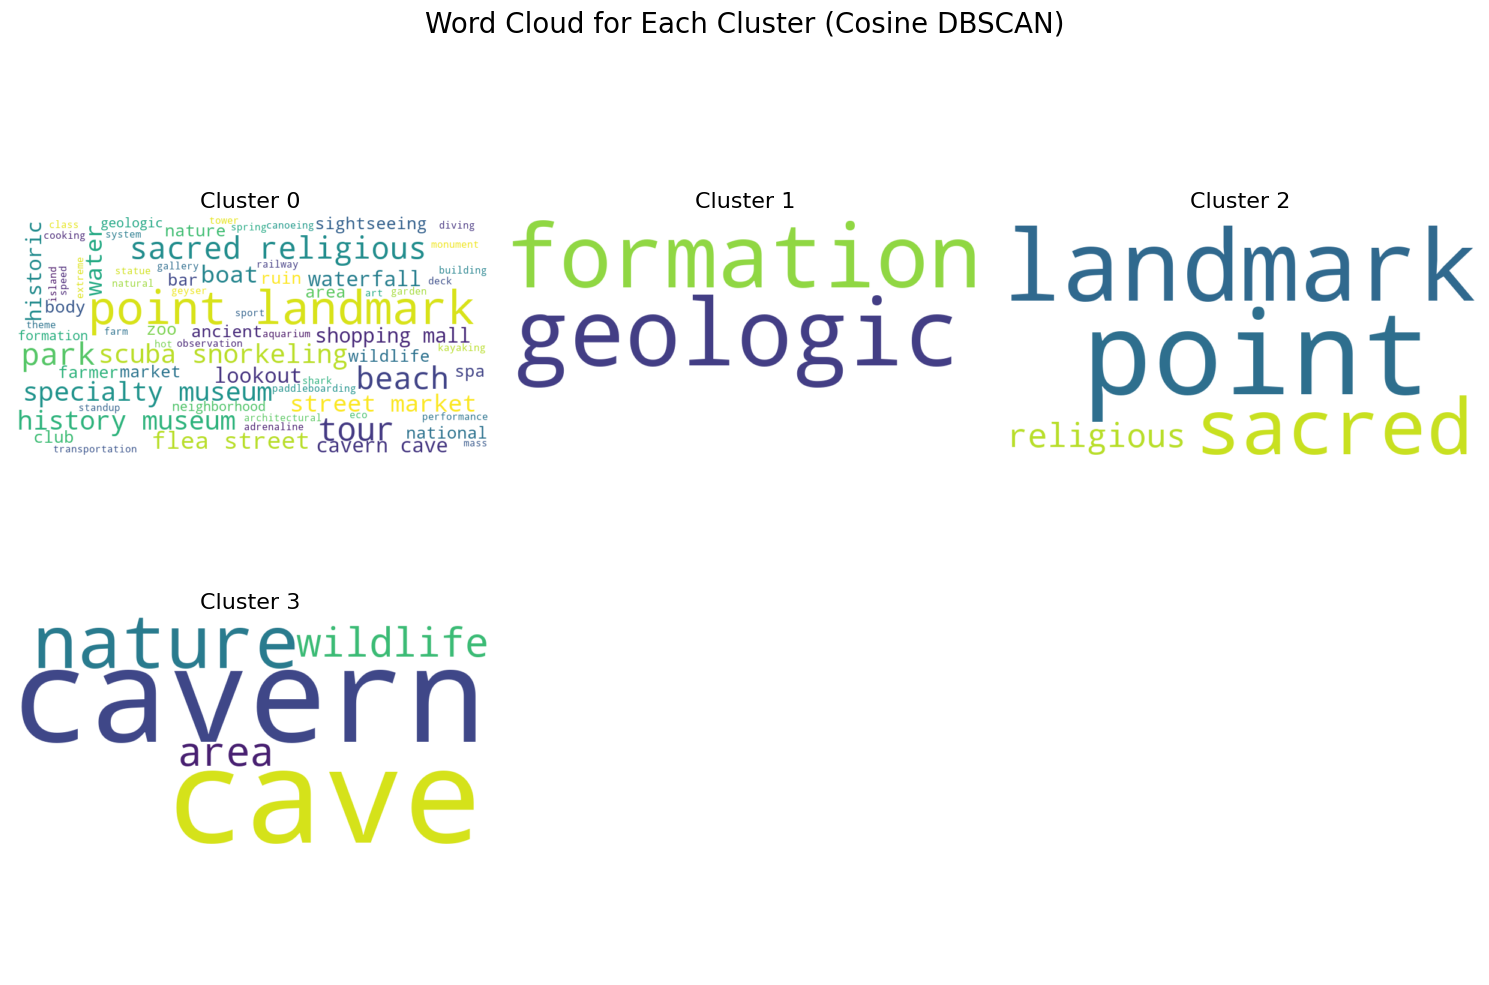

In [25]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

# Plot Word Clouds
num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster (Cosine DBSCAN)", fontsize=20)

axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [26]:
data_clusters

{0: ['history',
  'museum',
  'specialty',
  'museum',
  'bar',
  'club',
  'sacred',
  'religious',
  'boat',
  'tour',
  'body',
  'water',
  'point',
  'landmark',
  'lookout',
  'garden',
  'point',
  'landmark',
  'sightseeing',
  'tour',
  'hot',
  'spring',
  'geyser',
  'national',
  'park',
  'park',
  'flea',
  'street',
  'market',
  'shopping',
  'mall',
  'specialty',
  'museum',
  'historic',
  'historic',
  'ancient',
  'ruin',
  'zoo',
  'point',
  'landmark',
  'performance',
  'sacred',
  'religious',
  'sacred',
  'religious',
  'sacred',
  'religious',
  'monument',
  'statue',
  'specialty',
  'museum',
  'architectural',
  'building',
  'point',
  'landmark',
  'sacred',
  'religious',
  'ancient',
  'ruin',
  'point',
  'landmark',
  'point',
  'landmark',
  'sacred',
  'religious',
  'sacred',
  'religious',
  'nature',
  'wildlife',
  'area',
  'spa',
  'zoo',
  'point',
  'landmark',
  'waterfall',
  'farmer',
  'market',
  'natural',
  'history',
  'museum',


In [27]:
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_clusters.items()]))

# Save to Parquet
df.to_parquet("output/dbscan_clusters.parquet", index=False)